In [1]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from packages.bbox import bboxes_overlap, extract_and_save_crop
from PIL import Image

# Pré-processar dados

## Carregar dados

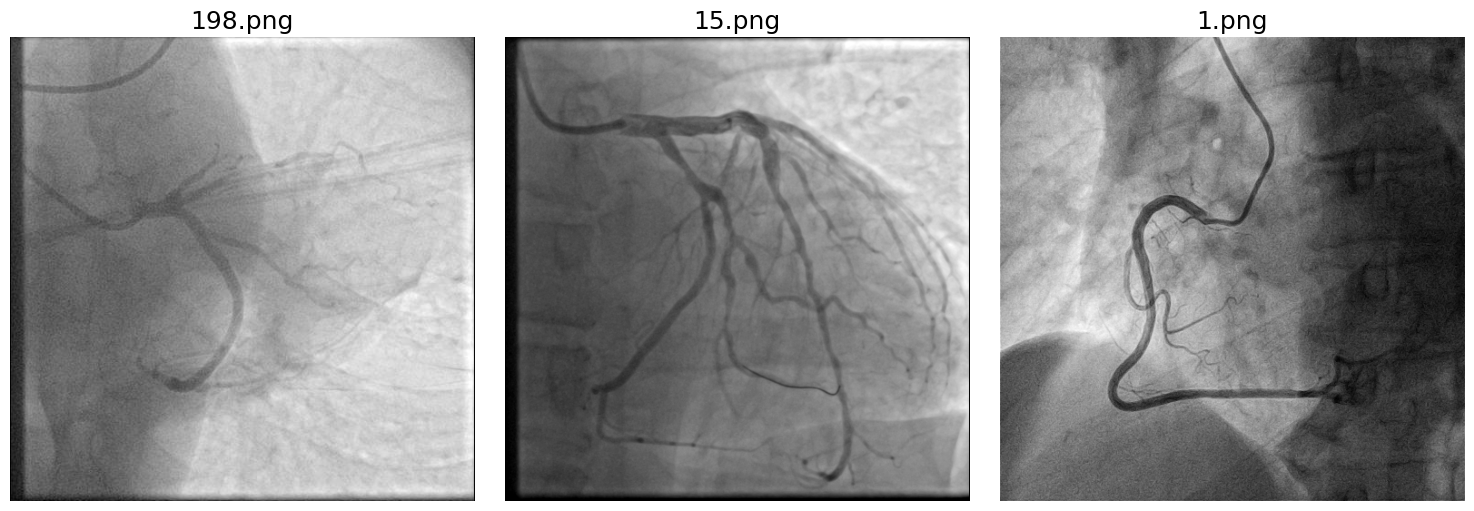

In [2]:
selected_images_path = ['../data/stenosis/train/images/198.png',
                        '../data/stenosis/test/images/15.png',
                        '../data/syntax/train/images/1.png']

images = []
for image_path in selected_images_path:
    image = Image.open(image_path)
    images.append(image)

fig, axs = plt.subplots(1, len(images), figsize=(15, 5))
for ax, img, path in zip(axs, images, selected_images_path):
    ax.imshow(img, cmap='gray')
    ax.set_title(os.path.basename(path), fontsize=18)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [3]:
subdirs = ['train', 'val', 'test']

def read_json(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    return data

data_syntrax = []
data_stenosis = []

for subdir in subdirs:
    syntrax_data = read_json(f'../data/syntax/{subdir}/annotations/{subdir}.json')
    stenosis_data = read_json(f'../data/stenosis/{subdir}/annotations/{subdir}.json')
    print(f'Loaded {len(syntrax_data["annotations"])} syntax annotations from {subdir}')
    print(f'Loaded {len(stenosis_data["annotations"])} stenosis annotations from {subdir}')

    for ann in syntrax_data['annotations']:
        ann['subset'] = subdir
        ann['set_type'] = 'syntax'
    for ann in stenosis_data['annotations']:
        ann['subset'] = subdir
        ann['set_type'] = 'stenosis'

    data_syntrax.extend(syntrax_data['annotations'])
    data_stenosis.extend(stenosis_data['annotations'])

Loaded 4976 syntax annotations from train
Loaded 1625 stenosis annotations from train
Loaded 1168 syntax annotations from val
Loaded 406 stenosis annotations from val
Loaded 1672 syntax annotations from test
Loaded 386 stenosis annotations from test


## Criar os DataFrames

In [4]:
df_syntrax = pd.DataFrame(data_syntrax)
df_syntrax.to_csv('../output/syntax_annotations.csv', index=False)
print('Syntax DataFrame shape:', df_syntrax.shape)
df_syntrax.head()

Syntax DataFrame shape: (7816, 10)


,id,image_id,category_id,segmentation,area,bbox,iscrowd,attributes,subset,set_type
0,1,922,8,"[[382.0, 350.75, 380.25, 349.5, 378.75, 348.5,...",442.0,"[341.0, 232.0, 41.0, 119.0]",0,{'occluded': False},train,syntax
1,2,922,6,"[[199.25, 112.19, 207.12, 116.31, 211.38, 115....",786.0,"[199.25, 106.81, 98.0, 47.07]",0,{'occluded': False},train,syntax
2,3,922,5,"[[183.62, 136.5, 188.12, 134.88, 192.88, 130.1...",323.0,"[178.12, 112.0, 24.88, 25.25]",0,{'occluded': False},train,syntax
3,4,922,7,"[[295.5, 151.75, 297.5, 148.88, 300.25, 150.25...",567.0,"[293.0, 148.88, 52.5, 85.12]",0,{'occluded': False},train,syntax
4,5,793,16,"[[266.0, 316.5, 267.25, 317.75, 271.5, 314.5, ...",540.0,"[238.88, 227.12, 34.62, 90.63]",0,{'occluded': False},train,syntax


In [5]:
df_stenosis = pd.DataFrame(data_stenosis)
df_stenosis.to_csv('../output/stenosis_annotations.csv', index=False)
print('Stenosis DataFrame shape:', df_stenosis.shape)
df_stenosis.head()

Stenosis DataFrame shape: (2417, 10)


,id,image_id,category_id,segmentation,area,bbox,iscrowd,attributes,subset,set_type
0,1,676,26,"[[278.0, 291.75, 286.75, 299.25, 289.5, 296.25...",708.0,"[278.0, 245.12, 42.75, 54.13]",0,{'occluded': False},train,stenosis
1,2,960,26,"[[294.75, 315.0, 293.0, 322.0, 298.5, 322.5, 3...",457.0,"[293.0, 315.0, 68.0, 23.25]",0,{'occluded': False},train,stenosis
2,3,960,26,"[[102.0, 172.25, 109.31, 179.25, 113.0, 175.75...",317.0,"[102.0, 157.38, 34.25, 21.87]",0,{'occluded': False},train,stenosis
3,4,960,26,"[[87.69, 192.62, 96.69, 198.75, 95.81, 203.0, ...",388.0,"[84.38, 192.62, 12.31, 43.63]",0,{'occluded': False},train,stenosis
4,5,99,26,"[[326.0, 232.62, 330.25, 231.38, 335.0, 239.75...",255.0,"[323.0, 221.25, 25.5, 26.13]",0,{'occluded': False},train,stenosis


## Classificar os segmentos em doentes e saudáveis

In [6]:
df_stenosis['label'] = 1
df_syntrax['label'] = 0

# Junta tudo em um único DataFrame
df_classificacao = pd.concat([df_stenosis, df_syntrax], ignore_index=True)

print(f"Total Doentes: {len(df_stenosis)}")
print(f"Total Saudáveis: {len(df_syntrax)}")
df_classificacao.head()

Total Doentes: 2417
Total Saudáveis: 7816


,id,image_id,category_id,segmentation,area,bbox,iscrowd,attributes,subset,set_type,label
0,1,676,26,"[[278.0, 291.75, 286.75, 299.25, 289.5, 296.25...",708.0,"[278.0, 245.12, 42.75, 54.13]",0,{'occluded': False},train,stenosis,1
1,2,960,26,"[[294.75, 315.0, 293.0, 322.0, 298.5, 322.5, 3...",457.0,"[293.0, 315.0, 68.0, 23.25]",0,{'occluded': False},train,stenosis,1
2,3,960,26,"[[102.0, 172.25, 109.31, 179.25, 113.0, 175.75...",317.0,"[102.0, 157.38, 34.25, 21.87]",0,{'occluded': False},train,stenosis,1
3,4,960,26,"[[87.69, 192.62, 96.69, 198.75, 95.81, 203.0, ...",388.0,"[84.38, 192.62, 12.31, 43.63]",0,{'occluded': False},train,stenosis,1
4,5,99,26,"[[326.0, 232.62, 330.25, 231.38, 335.0, 239.75...",255.0,"[323.0, 221.25, 25.5, 26.13]",0,{'occluded': False},train,stenosis,1


## Retirar os crops das imagens

In [7]:
# Criar diretórios para salvar os crops
os.makedirs('../output/crops/train', exist_ok=True)
os.makedirs('../output/crops/val', exist_ok=True)
os.makedirs('../output/crops/test', exist_ok=True)

# Adicionar coluna para armazenar o path do crop
df_classificacao['crop_path'] = ''

for idx, row in df_classificacao.iterrows():
    # Construir path da imagem original
    subset = row['subset']
    image_id = row['image_id']
    set_type = row['set_type']

    img_path = f'../data/{set_type}/{subset}/images/{image_id}.png'

    # Nome único para o crop
    crop_filename = f"{image_id}_{idx}.png"
    crop_path = f'../output/crops/{subset}/{crop_filename}'

    # Extrair e salvar o crop
    extract_and_save_crop(img_path, row['bbox'], crop_path)

    # Salvar path no DataFrame
    df_classificacao.at[idx, 'crop_path'] = crop_path

# Salvar DataFrame atualizado
df_classificacao.to_csv('../output/classification_annotations.csv', index=False)
print("Crops extraídos e paths salvos no DataFrame")

Crops extraídos e paths salvos no DataFrame


In [8]:
# Remover a coluna 'subset' se existir
if 'subset' in df_classificacao.columns:
    df_classificacao = df_classificacao.drop(columns=['subset'])

# Definir seed para reprodutibilidade
RANDOM_STATE = 42

# Separar conjunto de teste (20%)
df_train_val, df_test = train_test_split(
    df_classificacao,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_classificacao['label']  # Manter proporção das classes
)

# Separar treino de validação (75% / 25% do conjunto treino+val)
df_train, df_val = train_test_split(
    df_train_val,
    test_size=0.25,  # 25% de 80% = 20% do total
    random_state=RANDOM_STATE,
    stratify=df_train_val['label']
)

# Adicionar coluna 'subset' de volta
df_train['subset'] = 'train'
df_val['subset'] = 'val'
df_test['subset'] = 'test'

# Resetar índices
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# Salvar novo CSV
df_new = pd.concat([df_train, df_val, df_test], ignore_index=True)
df_new.to_csv('../output/classification_annotations_reshuffled.csv', index=False)